### Quantium Intern

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("QVI_purchase_behaviour.csv")
data = pd.read_csv("QVI_transaction_data(in).csv")

In [3]:
df.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [4]:
df["PREMIUM_CUSTOMER"].unique()

array(['Premium', 'Mainstream', 'Budget'], dtype=object)

In [5]:
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [6]:
data.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [7]:
print(df.columns.to_list())

['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER']


In [8]:
print(data.columns.to_list())

['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES']


In [9]:
df.dtypes

LYLTY_CARD_NBR       int64
LIFESTAGE           object
PREMIUM_CUSTOMER    object
dtype: object

In [10]:
data.dtypes

DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64
dtype: object

In [11]:
data["DATE"] = pd.to_datetime(data['DATE'], origin='1899-12-30', unit='D')

In [12]:
data["DATE"].head()

0   2018-10-17
1   2019-05-14
2   2019-05-20
3   2018-08-17
4   2018-08-18
Name: DATE, dtype: datetime64[ns]

In [13]:
data["brand"] = data["PROD_NAME"].str.split().str[0]
data["packet_size"] = data["PROD_NAME"].str.extract(r'(\d+)g', flags=re.IGNORECASE)

In [14]:
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,brand,packet_size
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,Natural,175
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,CCs,175
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,Smiths,170
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,Smiths,175
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,Kettle,150


In [15]:
df_merged = pd.merge(df, data, on='LYLTY_CARD_NBR', how='inner')

In [17]:
df_merged["brand"].unique()

array(['Natural', 'Red', 'Grain', 'WW', 'Cheetos', 'Infuzions', 'RRD',
       'Doritos', 'Old', 'GrnWves', 'Smiths', 'Kettle', 'CCs', 'Tostitos',
       'Cobs', 'Burger', 'Woolworths', 'Thins', 'Tyrrells', 'Smith',
       'Cheezels', 'Twisties', 'Sunbites', 'Snbts', 'Pringles', 'French',
       'Infzns', 'Dorito', 'NCC'], dtype=object)

In [18]:
df_merged["packet_size"].unique()

array(['175', '150', '210', '160', '165', '110', '330', '170', '300',
       '180', '135', '70', '220', '190', '270', '90', '200', '134', '380',
       '125', '250'], dtype=object)

In [19]:
df_merged["packet_size"] = pd.to_numeric(df_merged["packet_size"])

In [20]:
df_merged["packet_size"].isna().sum()

np.int64(0)

In [21]:
clean_brand = {
    'Smith': 'Smiths',
    'Snbts': 'Sunbites',
    'Infzns': 'Infuzions',
    'Dorito': 'Doritos',
    'GrnWves': 'Grain',
    'NCC': 'Natural',
    'RRD': 'Red',
    'WW': 'Woolworths'
}
df_merged["brand"] = df_merged["brand"].replace(clean_brand)

In [24]:
df_merged["TOT_SALES"].describe()

count    264836.000000
mean          7.304200
std           3.083226
min           1.500000
25%           5.400000
50%           7.400000
75%           9.200000
max         650.000000
Name: TOT_SALES, dtype: float64

In [25]:
df_merged[df_merged["TOT_SALES"] == 650]

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,brand,packet_size
221625,226000,OLDER FAMILIES,Premium,2018-08-19,226,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,Doritos,380
221626,226000,OLDER FAMILIES,Premium,2019-05-20,226,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,Doritos,380


In [26]:
df_merged[df_merged["PROD_QTY"] == 200]

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,brand,packet_size
221625,226000,OLDER FAMILIES,Premium,2018-08-19,226,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,Doritos,380
221626,226000,OLDER FAMILIES,Premium,2019-05-20,226,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,Doritos,380


In [27]:
df_merged = df_merged[df_merged["PROD_QTY"]!=200]

In [28]:
df_merged["TOT_SALES"].max()

np.float64(29.5)

#### ====================================================
#### Now, we want to see which dates the data been in


In [30]:
df_merged["DATE"].min()

Timestamp('2018-07-01 00:00:00')

In [31]:
df_merged["DATE"].max()

Timestamp('2019-06-30 00:00:00')

#### ====================================================
#### Here we want to see what is the most and best segments 
#### from Outside analysis

In [35]:
df_merged.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"].sum().reset_index().sort_values("TOT_SALES", ascending=False)

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
6,OLDER FAMILIES,Budget,168363.25
19,YOUNG SINGLES/COUPLES,Mainstream,157621.60
13,RETIREES,Mainstream,155677.05
15,YOUNG FAMILIES,Budget,139345.85
9,OLDER SINGLES/COUPLES,Budget,136769.80
10,OLDER SINGLES/COUPLES,Mainstream,133393.80
11,OLDER SINGLES/COUPLES,Premium,132263.15
12,RETIREES,Budget,113147.80
7,OLDER FAMILIES,Mainstream,103445.55
14,RETIREES,Premium,97646.05


##### Firstly, We founded that the highest 3 segments as you see is OLDER FAMILIES with Budget and YOUNG SINGLES/COUPLES with Mainstream and the third segment is for RETIREES with Mainstream condition.
##### ========================================================

### Is these highing ranking for these segments is for the count of customers in each segment????

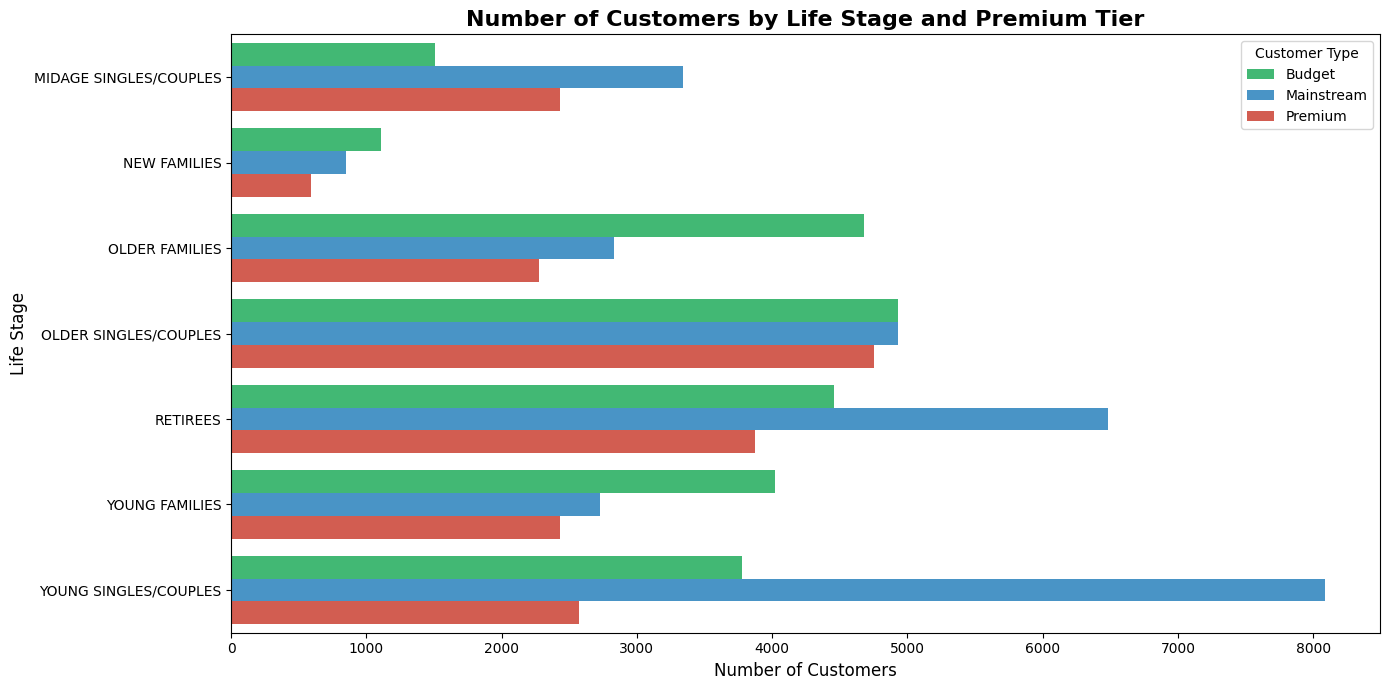

In [36]:
# Prepare the data
customer_counts = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
customer_counts.columns = ['LIFESTAGE', 'PREMIUM_CUSTOMER', 'NUM_CUSTOMERS']

# Plot
plt.figure(figsize=(14, 7))
sns.barplot(
    data=customer_counts,
    x='NUM_CUSTOMERS',
    y='LIFESTAGE',
    hue='PREMIUM_CUSTOMER',
    palette={'Budget': '#2ecc71', 'Mainstream': '#3498db', 'Premium': '#e74c3c'}
)

plt.title('Number of Customers by Life Stage and Premium Tier', fontsize=16, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Life Stage', fontsize=12)
plt.legend(title='Customer Type')
plt.tight_layout()
plt.show()

##### From this visualization, I see that for the two segments of YOUNG SINGLES/COUPLES FOR Mainstream and RETIREES for mainstream, the high number of customers is a higly cause of spending, 
##### ,But for OLDER FAMILIES, IT must have another reason for these expenditures.
##### ========================================

#### may be the price of each transation for each segment, may affect the spendings

In [37]:
df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    AVG_SALES=('TOT_SALES', 'mean'),
    NUM_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique')
).reset_index().sort_values('AVG_SALES', ascending=False)

,LIFESTAGE,PREMIUM_CUSTOMER,AVG_SALES,NUM_CUSTOMERS
1,MIDAGE SINGLES/COUPLES,Mainstream,7.647284,3340
19,YOUNG SINGLES/COUPLES,Mainstream,7.558339,8088
14,RETIREES,Premium,7.456174,3872
11,OLDER SINGLES/COUPLES,Premium,7.449766,4750
12,RETIREES,Budget,7.443445,4454
9,OLDER SINGLES/COUPLES,Budget,7.430315,4929
4,NEW FAMILIES,Mainstream,7.317806,849
3,NEW FAMILIES,Budget,7.297321,1112
15,YOUNG FAMILIES,Budget,7.287201,4017
10,OLDER SINGLES/COUPLES,Mainstream,7.282116,4930


#### Unfortunatily, We found it not like we think for the price of each process as they are more close to each other
#### ========================================

#### for older families, the counts of the clients don't effect the TOTAL SALES and also the price of each transaction,
#### ,BUT may be each customer comes again and again, what i mean is THE Number of times the customer visits the store.
#### ==================================

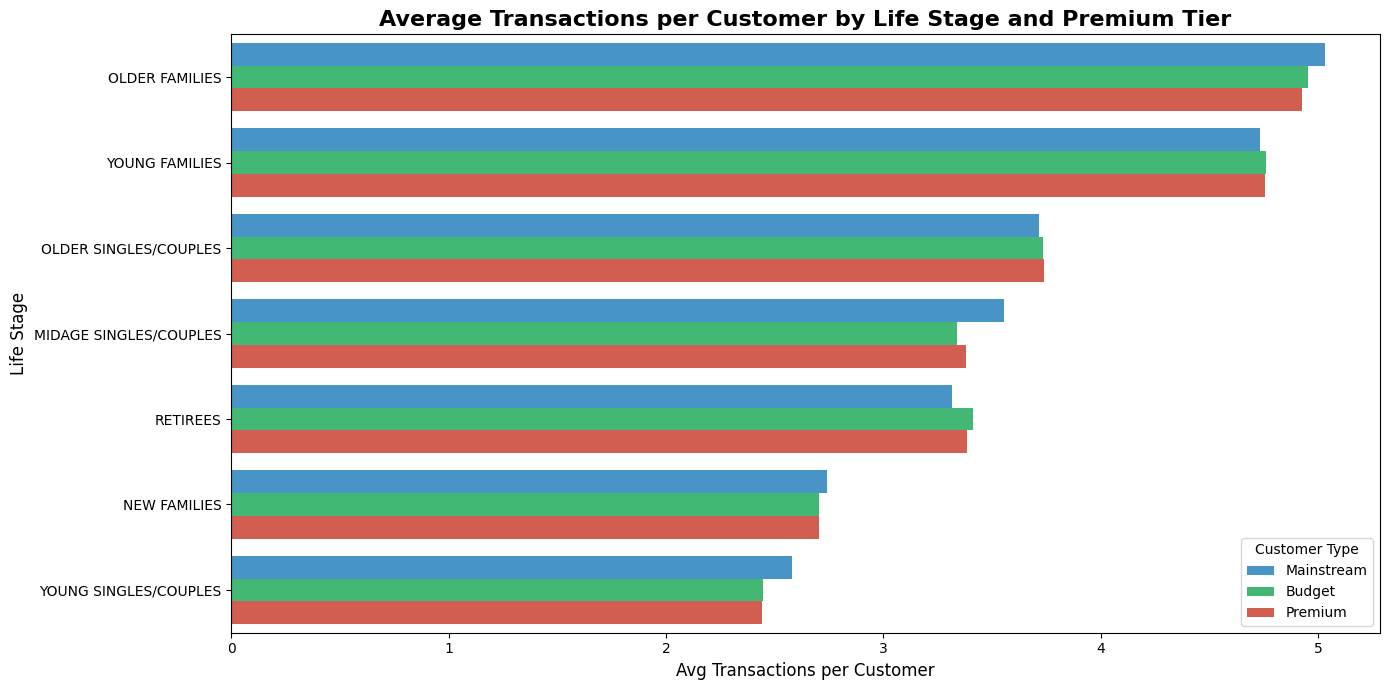

In [38]:
num_transaction_per_customer = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    AVG_TRANSACTIONS=('TXN_ID', 'count'),
    NUM_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique')
).assign(AVG_TXN_PER_CUSTOMER=lambda x: x['AVG_TRANSACTIONS'] / x['NUM_CUSTOMERS']).reset_index().sort_values('AVG_TXN_PER_CUSTOMER', ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=num_transaction_per_customer,
    x='AVG_TXN_PER_CUSTOMER',
    y='LIFESTAGE',
    hue='PREMIUM_CUSTOMER',
    palette={'Budget': '#2ecc71', 'Mainstream': '#3498db', 'Premium': '#e74c3c'}
)
plt.title('Average Transactions per Customer by Life Stage and Premium Tier', fontsize=16, fontweight='bold')
plt.xlabel('Avg Transactions per Customer', fontsize=12)
plt.ylabel('Life Stage', fontsize=12)
plt.legend(title='Customer Type')
plt.tight_layout()
plt.show()

##### Yes, it's it, it effects on the total sales as the Highest segment is OLDER FAMILIES, but what i see is that, the 3 three categories of the OLDER FAMILIES IS HIGH, for this it affects,
#### ,BUT it's not the main cause for this highest ranking in total sales, Actually, there's another reason and as we know, we will find it
##### =======================================

##### Let's try if the price of each unit sold affects or different in each segment, We know that it will be slightly different as we saw before in the analysis of average price for each transaction for each segment, but we here only want to know which segment buy with the highest price.

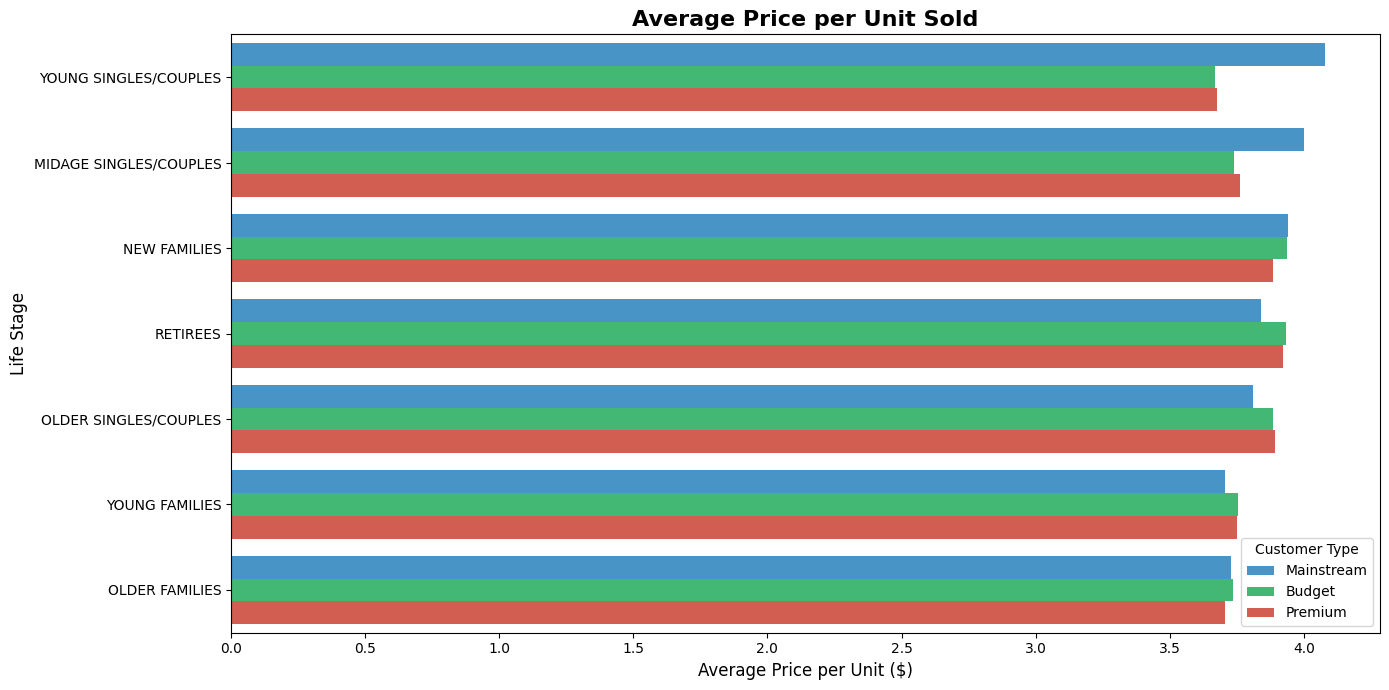

In [40]:
avg_price_per_unit_sold = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    AVG_TRANSACTIONS=('TXN_ID', 'count'),
    NUM_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique'),
    TOT_SALES=('TOT_SALES', 'sum'),
    TOT_UNITS=('PROD_QTY', 'sum')
).assign(
    AVG_PRICE_PER_UNIT=lambda x: x['TOT_SALES'] / x['TOT_UNITS']
).reset_index().sort_values('AVG_PRICE_PER_UNIT', ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=avg_price_per_unit_sold,
    x='AVG_PRICE_PER_UNIT',
    y='LIFESTAGE',
    hue='PREMIUM_CUSTOMER',
    palette={'Budget': '#2ecc71', 'Mainstream': '#3498db', 'Premium': '#e74c3c'}
)
plt.title("Average Price per Unit Sold", fontsize=16, fontweight='bold')
plt.xlabel('Average Price per Unit ($)', fontsize=12)
plt.ylabel("Life Stage", fontsize=12)
plt.legend(title='Customer Type')
plt.tight_layout()
plt.show()

##### We founded that the YOUNG SINGLES/COUPLES for Mainstream spends more than any segment even from Premium segments.

##### Now, let's move to see which brand used to use it in the marketing.

In [42]:
df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'brand']).agg(
    AVG_TRANSACTIONS=('TXN_ID', 'count'),
    NUM_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique'),
    AVG_SALES=('TOT_SALES', 'mean')
).assign(
    AVG_TXN_PER_CUSTOMER=lambda x: x['AVG_TRANSACTIONS'] / x['NUM_CUSTOMERS'],
    TOT_SALES_SEGMENT=lambda x: x['NUM_CUSTOMERS'] * x['AVG_TXN_PER_CUSTOMER'] * x['AVG_SALES']
).reset_index().sort_values('TOT_SALES_SEGMENT', ascending=False)

,LIFESTAGE,PREMIUM_CUSTOMER,brand,AVG_TRANSACTIONS,NUM_CUSTOMERS,AVG_SALES,AVG_TXN_PER_CUSTOMER,TOT_SALES_SEGMENT
408,YOUNG SINGLES/COUPLES,Mainstream,Kettle,3844,3065,9.215297,1.254160,35423.6
135,OLDER FAMILIES,Budget,Kettle,3320,2249,9.656024,1.476212,32058.0
282,RETIREES,Mainstream,Kettle,3386,2551,9.348021,1.327323,31652.4
198,OLDER SINGLES/COUPLES,Budget,Kettle,3065,2229,9.483328,1.375056,29066.4
240,OLDER SINGLES/COUPLES,Premium,Kettle,2947,2127,9.481982,1.385520,27943.4
...,...,...,...,...,...,...,...,...
84,NEW FAMILIES,Mainstream,Burger,14,13,4.435714,1.076923,62.1
120,NEW FAMILIES,Premium,Sunbites,16,15,2.868750,1.066667,45.9
99,NEW FAMILIES,Mainstream,Sunbites,15,15,2.946667,1.000000,44.2
105,NEW FAMILIES,Premium,Burger,8,8,3.737500,1.000000,29.9


##### OOP's, we founded that the highest brand for the highests 8 TOTAL SALES is the brand of Kettle, and that's means, It's a global brand for all the segments.
##### =====================================

#### Also, Let's move to see which Packet size is being sold and achieved more Total sales.

In [43]:
df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'packet_size'])["TOT_SALES"].sum().reset_index().sort_values("TOT_SALES", ascending= False)

,LIFESTAGE,PREMIUM_CUSTOMER,packet_size,TOT_SALES
136,OLDER FAMILIES,Budget,175,42204.7
283,RETIREES,Mainstream,175,38242.7
409,YOUNG SINGLES/COUPLES,Mainstream,175,37967.9
325,YOUNG FAMILIES,Budget,175,35634.8
199,OLDER SINGLES/COUPLES,Budget,175,34497.0
...,...,...,...,...
85,NEW FAMILIES,Mainstream,90,44.2
116,NEW FAMILIES,Premium,180,37.2
84,NEW FAMILIES,Mainstream,70,36.0
105,NEW FAMILIES,Premium,70,31.2


##### Finally, let's try to see which month of the year, sold more chips

In [44]:
df_merged["MONTH"]=df_merged["DATE"].dt.to_period("M")
df_merged.groupby(["MONTH"])["TOT_SALES"].sum().reset_index().sort_values("TOT_SALES", ascending= False)

,MONTH,TOT_SALES
5,2018-12,167913.40
8,2019-03,166265.20
0,2018-07,165275.30
3,2018-10,164415.70
6,2019-01,162642.30
11,2019-06,160538.60
2,2018-09,160522.00
4,2018-11,160233.70
9,2019-04,159845.10
1,2018-08,158081.05


#### Here we see that it's in a small range and every month has close sales to the others, but we can see that in December there's high saling and that actually for the chrismats.

### VISUALISING THE DATA

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

##### VISUALISING THE TOTAL SALES BY SEGMENT

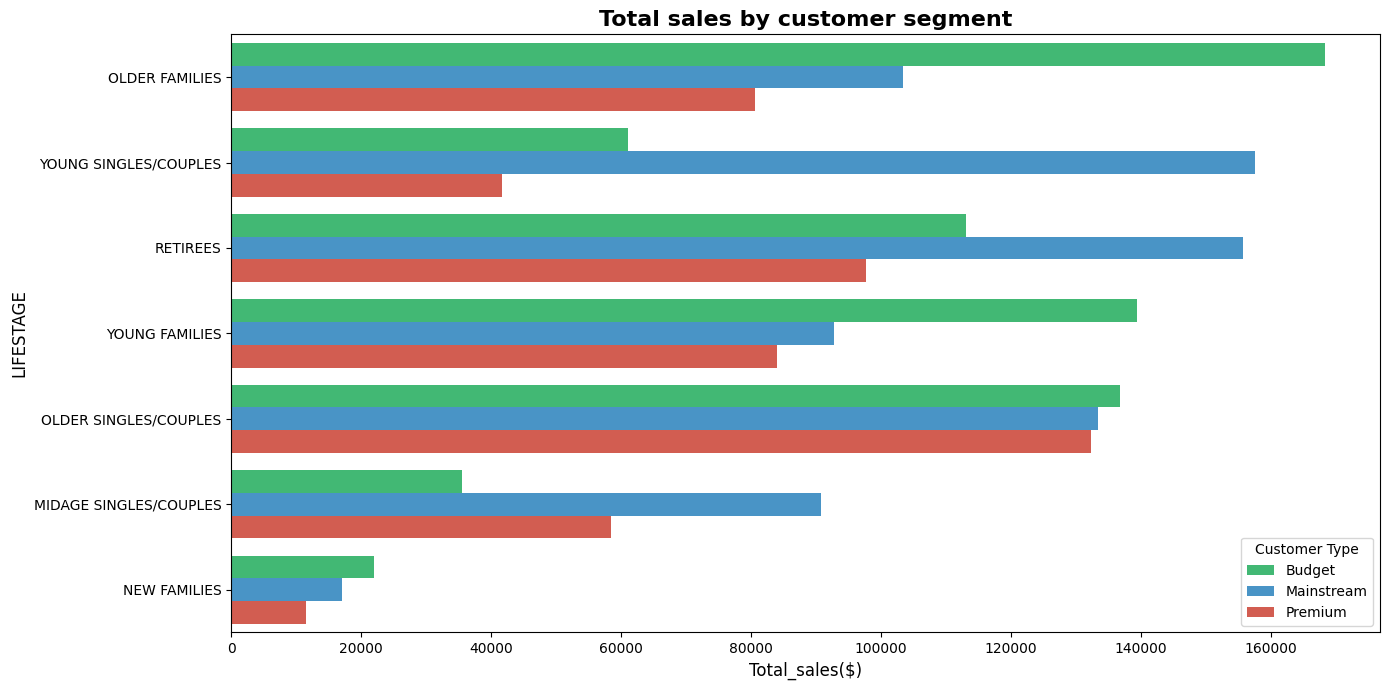

In [46]:
segment_sales = df_merged.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"].sum().reset_index().sort_values("TOT_SALES", ascending= False)
plt.figure(figsize=(14, 7))
sns.barplot(data=segment_sales, x="TOT_SALES", y="LIFESTAGE", hue="PREMIUM_CUSTOMER", palette={'Budget': '#2ecc71', 'Mainstream': '#3498db', 'Premium': '#e74c3c'})
plt.title("Total sales by customer segment", fontsize=16, fontweight='bold')
plt.xlabel('Total_sales($)', fontsize=12)
plt.ylabel("LIFESTAGE", fontsize=12)
plt.legend(title= 'Customer Type')
plt.tight_layout()
plt.show()

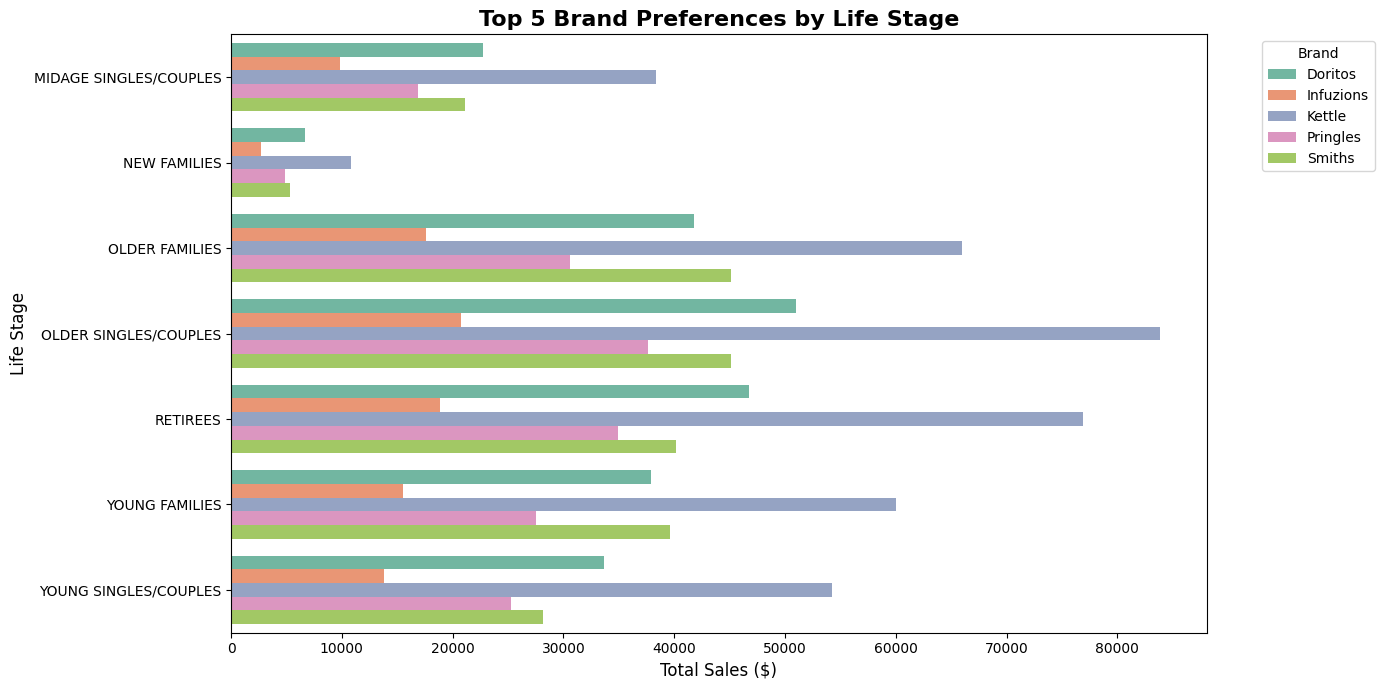

In [47]:
# Get top 5 brands overall first
top5_brands = df_merged.groupby('brand')['TOT_SALES'].sum().nlargest(5).index

# Filter data for top 5 brands only
brand_data = df_merged[df_merged['brand'].isin(top5_brands)].groupby(['LIFESTAGE', 'brand'])['TOT_SALES'].sum().reset_index()

# Plot
plt.figure(figsize=(14, 7))
sns.barplot(
    data=brand_data,
    x='TOT_SALES',
    y='LIFESTAGE',
    hue='brand',
    palette='Set2'
)

plt.title('Top 5 Brand Preferences by Life Stage', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Life Stage', fontsize=12)
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

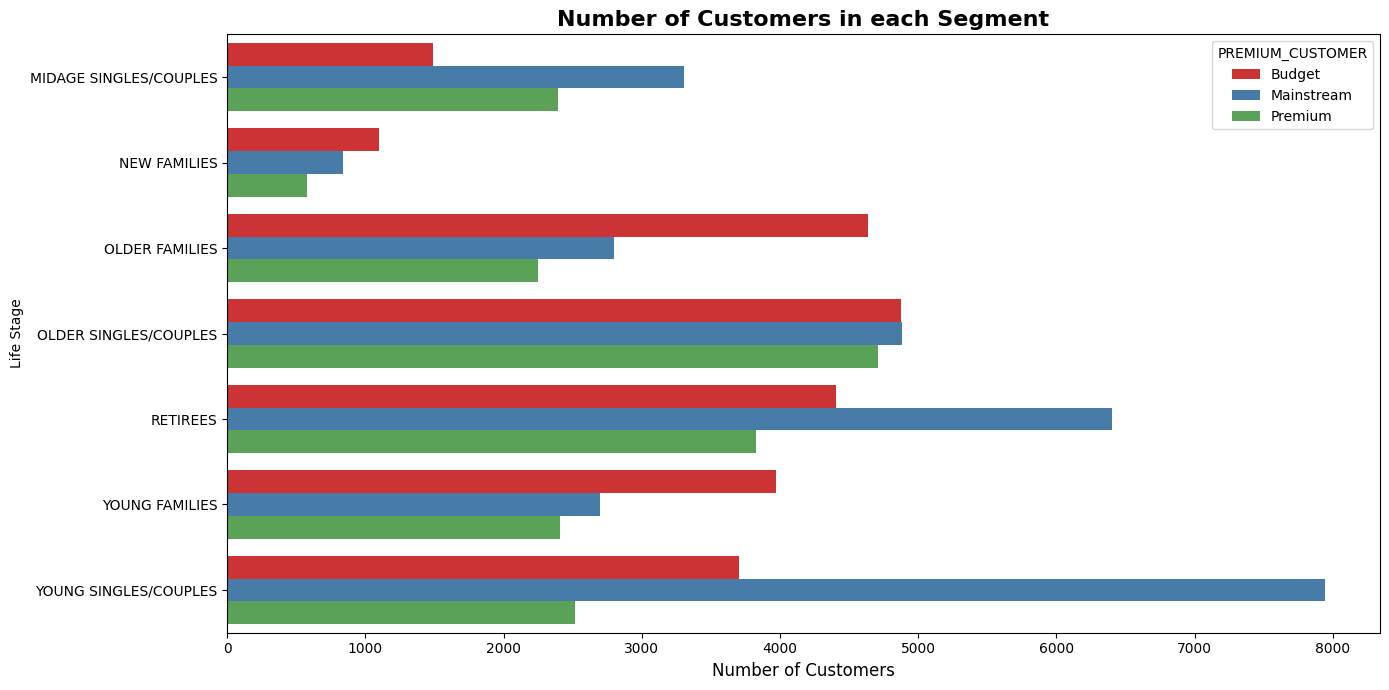

In [63]:
segment_customer_number = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
segment_customer_number.columns = ['LIFESTAGE', 'PREMIUM_CUSTOMER', 'NUM_CUSTOMERS']

plt.figure(figsize=(14, 7))
sns.barplot(
    data=segment_customer_number,
    x='NUM_CUSTOMERS',
    y='LIFESTAGE',
    hue='PREMIUM_CUSTOMER',
    palette='Set1'
)
plt.title("Number of Customers in each Segment", fontsize=16, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Life Stage')
plt.tight_layout()
plt.show()

#### NOTE:  We will specify which which packet size been sold more not what achieve more sales as the more in weight, the more in total sales and that's not what we mean, we mean, what the people prefer and buy more

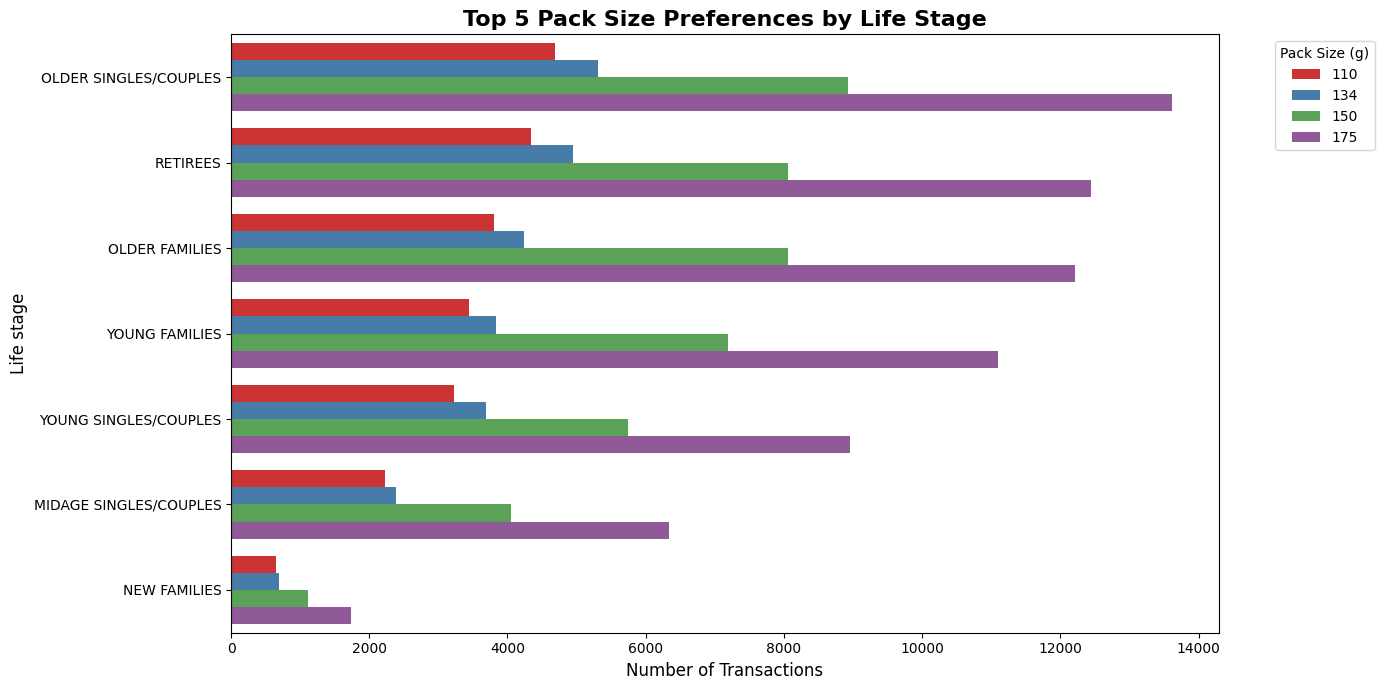

In [48]:
top4_packet_sizes = df_merged.groupby("packet_size")["TXN_ID"].count().nlargest(4).index
packet_size_data = df_merged[df_merged["packet_size"].isin(top4_packet_sizes)].groupby(["LIFESTAGE", "packet_size"])["TXN_ID"].count().reset_index().sort_values("TXN_ID", ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(data= packet_size_data, x="TXN_ID", y="LIFESTAGE", hue="packet_size", palette='Set1')
plt.title('Top 5 Pack Size Preferences by Life Stage', fontsize=16, fontweight='bold')
plt.xlabel("Number of Transactions", fontsize=12)
plt.ylabel("Life stage", fontsize= 12)
plt.legend(title='Pack Size (g)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


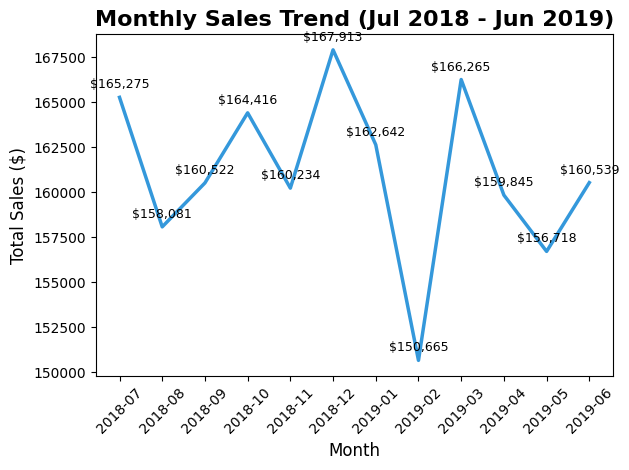

In [50]:
monthly_sales = df_merged.groupby(["MONTH"])["TOT_SALES"].sum().reset_index()
monthly_sales["MONTH"]= monthly_sales['MONTH'].astype(str)
plt.Figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x=monthly_sales["MONTH"], y=monthly_sales["TOT_SALES"], markers='o', linewidth = 2.5,     color='#3498db')
# Add value labels on each point
for i, row in monthly_sales.iterrows():
    plt.text(i, row['TOT_SALES'] + 500, f"${row['TOT_SALES']:,.0f}", 
             ha='center', fontsize=9, color='black')

plt.title('Monthly Sales Trend (Jul 2018 - Jun 2019)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
from collections import Counter

# Split all product names into individual words
all_words = ' '.join(df_merged['PROD_NAME'].unique()).split()

# Count each word
word_counts = Counter(all_words)

# Convert to dataframe and sort
word_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Count']).sort_values('Count', ascending=False)

print(word_df.head(20))

         Word  Count
72       175g     26
22      Chips     21
9        150g     19
55          &     17
59     Smiths     16
60    Crinkle     14
61        Cut     14
63     Kettle     13
81       Salt     12
39     Cheese     12
20   Original     10
1        Chip      9
38    Doritos      9
47      Salsa      9
26       165g      8
67       Corn      8
32        RRD      8
43       170g      8
150  Pringles      8
153      134g      8


In [54]:
# Find all product names containing 'Salsa'
df_merged[df_merged['PROD_NAME'].str.contains('Salsa', case=False)]['PROD_NAME'].unique()

array(['Old El Paso Salsa   Dip Tomato Med 300g',
       'Red Rock Deli SR    Salsa & Mzzrlla 150g',
       'Doritos Salsa       Medium 300g',
       'Old El Paso Salsa   Dip Tomato Mild 300g',
       'Woolworths Medium   Salsa 300g', 'Woolworths Mild     Salsa 300g',
       'Doritos Salsa Mild  300g',
       'Old El Paso Salsa   Dip Chnky Tom Ht300g',
       'Smiths Crinkle Cut  Tomato Salsa 150g'], dtype=object)

In [55]:
non_chips = [
    'Old El Paso Salsa   Dip Tomato Med 300g',
    'Old El Paso Salsa   Dip Tomato Mild 300g',
    'Old El Paso Salsa   Dip Chnky Tom Ht300g',
    'Woolworths Medium   Salsa 300g',
    'Woolworths Mild     Salsa 300g'
]

df_merged = df_merged[~df_merged['PROD_NAME'].isin(non_chips)]

In [56]:
import re

# Split all product names into individual words
all_words = ' '.join(df_merged['PROD_NAME'].unique()).split()

# Remove words with digits and special characters
clean_words = [word for word in all_words if re.match(r'^[A-Za-z]+$', word)]

# Count and sort
word_counts = Counter(clean_words)
word_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Count']).sort_values('Count', ascending=False)

print(word_df.head(20))

         Word  Count
16      Chips     21
37     Smiths     16
38    Crinkle     14
39        Cut     14
41     Kettle     13
29     Cheese     12
57       Salt     12
14   Original     10
28    Doritos      9
1        Chip      9
22        RRD      8
45       Corn      8
107  Pringles      8
47    Chicken      7
13         WW      7
9        Sour      6
56        Sea      6
58    Vinegar      5
35     Chilli      5
79     Crisps      5


In [57]:
df_merged.groupby('DATE')['TXN_ID'].count().reset_index().sort_values('DATE')

,DATE,TXN_ID
0,2018-07-01,684
1,2018-07-02,667
2,2018-07-03,691
3,2018-07-04,685
4,2018-07-05,667
...,...,...
359,2019-06-26,675
360,2019-06-27,679
361,2019-06-28,695
362,2019-06-29,717


In [58]:
# Create a full date range
full_dates = pd.date_range(start='2018-07-01', end='2019-06-30')

# Find missing dates
missing_dates = full_dates[~full_dates.isin(df_merged['DATE'])]
print(missing_dates)

DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')


C:\Users\mm osman\AppData\Local\Temp\ipykernel_8704\2446987614.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


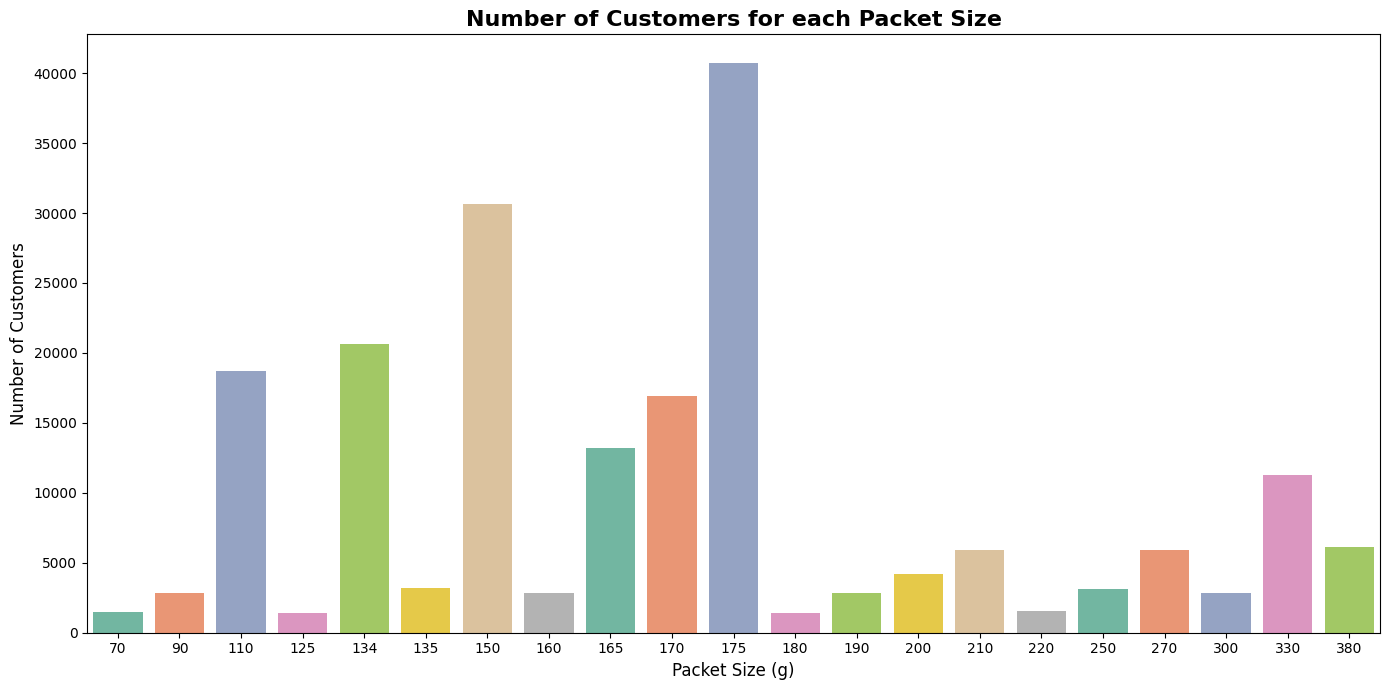

In [60]:
packet_size_data2 = df_merged.groupby('packet_size')['LYLTY_CARD_NBR'].nunique().reset_index()
packet_size_data2.columns = ['packet_size', 'NUM_CUSTOMERS']

plt.figure(figsize=(14, 7))
sns.barplot(
    data=packet_size_data2,
    x='packet_size',
    y='NUM_CUSTOMERS',
    palette='Set2'
)
plt.title('Number of Customers for each Packet Size', fontsize=16, fontweight='bold')
plt.xlabel('Packet Size (g)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.tight_layout()
plt.show()

### t-test for comparing the two segments of Mainstream vs Premium and young singles/couples and MID AGE segment

In [64]:
from scipy.stats import ttest_ind